In [1]:
import torch
from torchvision import datasets, models, transforms
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from Trainer import Trainer

from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### ResNet 152

In [2]:
class TransferLearningNetwork(nn.Module):
    def __init__(self):
        super(TransferLearningNetwork, self).__init__()

        # Load pre-trained ResNet model
        resnet = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(device)

        # Freeze the parameters of the pre-trained ResNet
        for param in resnet.parameters():
            param.requires_grad = False

        # Modify the last layer to match the number of classes
        num_ftrs = resnet.fc.in_features
        resnet.fc = nn.Sequential(
                            nn.Linear(num_ftrs, 1),
                            nn.Sigmoid()).to(device)

        self.resnet = resnet

    def forward(self, x):
        x = self.resnet(x)
        return x.view(-1)
    
model = TransferLearningNetwork().to(device)
optimizer = optim.Adam(model.resnet.fc.parameters(), lr=1e-3)

In [27]:
trainer = Trainer(data_path="/dtu/datasets1/02514/hotdog_nothotdog/",
                 image_size=512,
                 batch_size=64,
                 normalize=True)

out_dict = trainer.train(model, optimizer, num_epochs=10)


The code will run on GPU.


  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.184	 test: 0.188	 Accuracy train: 94.7%	 test: 93.8%


  0%|          | 0/32 [00:00<?, ?it/s]

...

Loss train: 0.126	 test: 0.144	 Accuracy train: 96.8%	 test: 95.5%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.126	 test: 0.143	 Accuracy train: 96.5%	 test: 95.5%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.119	 test: 0.138	 Accuracy train: 97.0%	 test: 95.6%


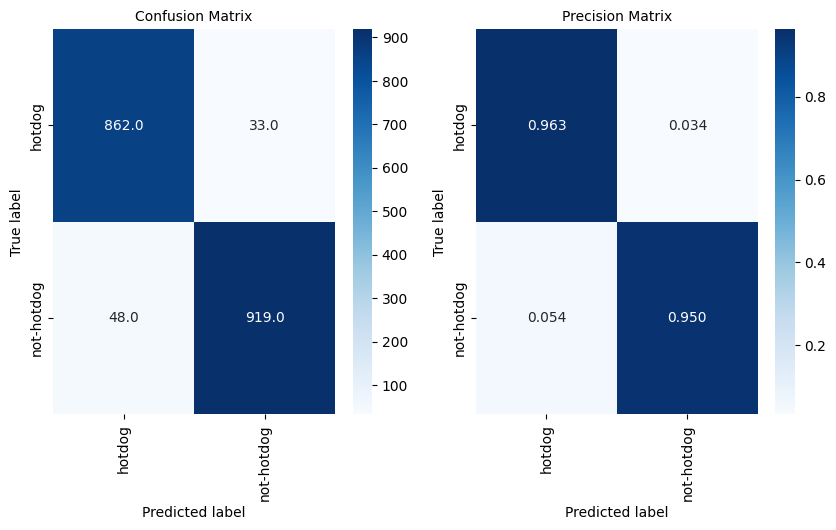

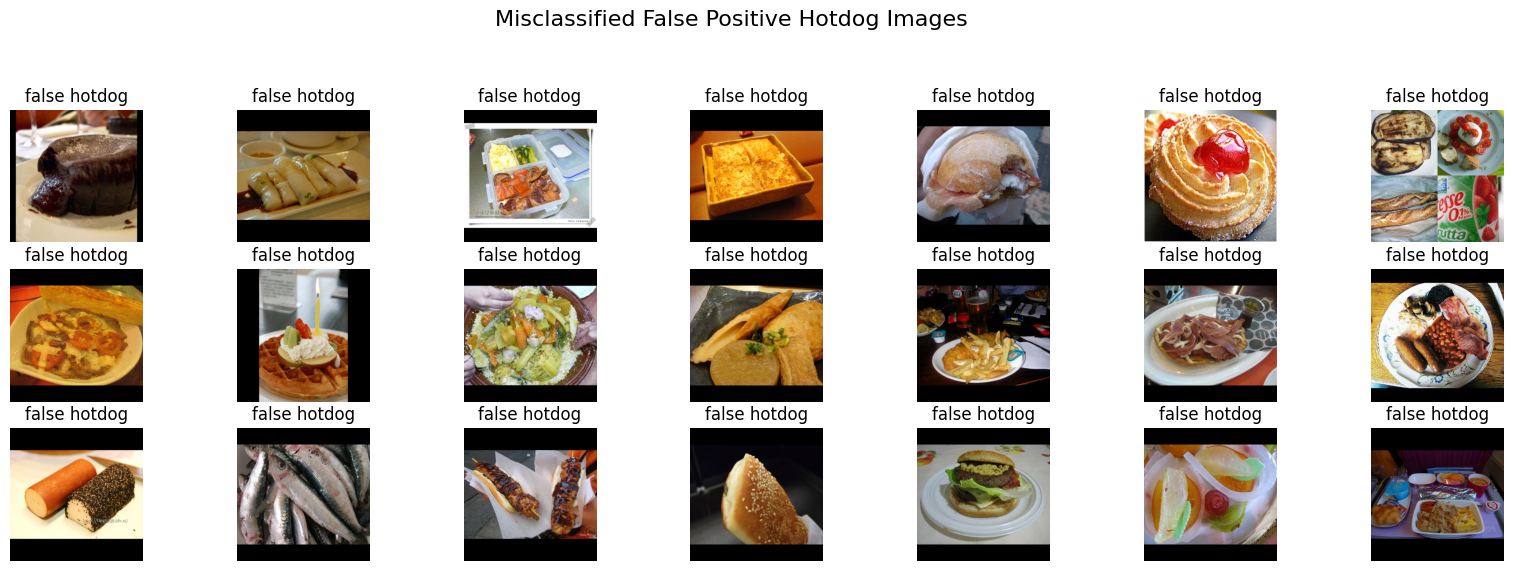

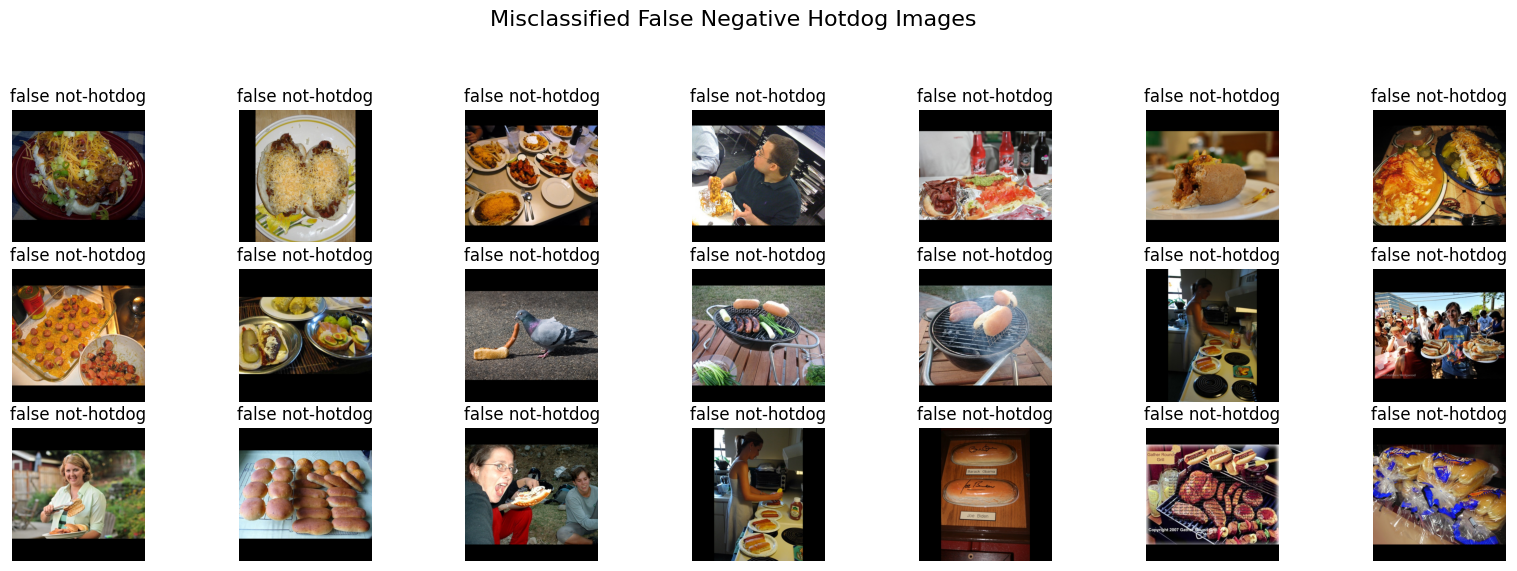

In [28]:
trainer.confusionMatrix(model, show_images = True)

### VGG16

In [10]:
class TransferLearningNetwork(nn.Module):
    def __init__(self):
        super(TransferLearningNetwork, self).__init__()

        # Load pre-trained ResNet model
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)

        # Freeze the parameters of the pre-trained ResNet
        for param in model.parameters():
            param.requires_grad = False

        # Modify the last layer to match the number of classes
        num_features = model.classifier[6].in_features
        features = list(model.classifier.children())[:-1] # Remove last layer
        features.extend([nn.Linear(num_features, 1), nn.Sigmoid()]) # Add our layer with 4 outputs
        model.classifier = nn.Sequential(*features) # Replace the model classifier

        self.model = model

    def forward(self, x):
        x = self.model(x)
        return x.view(-1)
    
model = TransferLearningNetwork().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [15]:
trainer = Trainer(data_path="/dtu/datasets1/02514/hotdog_nothotdog/",
                 image_size=128,
                 batch_size=128,
                 normalize=True)

out_dict = trainer.train(model, optimizer, num_epochs=10)


The code will run on GPU.


  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Loss train: 0.210	 test: 0.222	 Accuracy train: 91.3%	 test: 90.8%


  0%|          | 0/16 [00:00<?, ?it/s]

...

Loss train: 0.170	 test: 0.211	 Accuracy train: 93.8%	 test: 91.0%


  0%|          | 0/16 [00:00<?, ?it/s]

Loss train: 0.158	 test: 0.217	 Accuracy train: 92.9%	 test: 90.7%


  0%|          | 0/16 [00:00<?, ?it/s]

Loss train: 0.162	 test: 0.217	 Accuracy train: 93.8%	 test: 91.0%


### EfficientNet

In [30]:
class TransferLearningNetwork(nn.Module):
    def __init__(self):
        super(TransferLearningNetwork, self).__init__()

        # Load pre-trained ResNet model
        model = models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.DEFAULT).to(device)

        # Freeze the parameters of the pre-trained ResNet
        for param in model.parameters():
            param.requires_grad = False

        # Modify the last layer to match the number of classes
        num_features = model.classifier[1].in_features
        features = list(model.classifier.children())[:-1] # Remove last layer
        features.extend([nn.Linear(num_features, 1), nn.Sigmoid()]) # Add our layer with 4 outputs
        model.classifier = nn.Sequential(*features) # Replace the model classifier

        self.model = model

    def forward(self, x):
        x = self.model(x)
        return x.view(-1)
    
model = TransferLearningNetwork().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [31]:
trainer = Trainer(data_path="/dtu/datasets1/02514/hotdog_nothotdog/",
                 image_size=512,
                 batch_size=64,
                 normalize=True)

out_dict = trainer.train(model, optimizer, num_epochs=10)


The code will run on GPU.


  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.500	 test: 0.441	 Accuracy train: 82.2%	 test: 84.9%


  0%|          | 0/32 [00:00<?, ?it/s]

...

Loss train: 0.170	 test: 0.134	 Accuracy train: 94.1%	 test: 95.8%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.163	 test: 0.131	 Accuracy train: 94.4%	 test: 95.8%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.163	 test: 0.129	 Accuracy train: 94.5%	 test: 96.0%


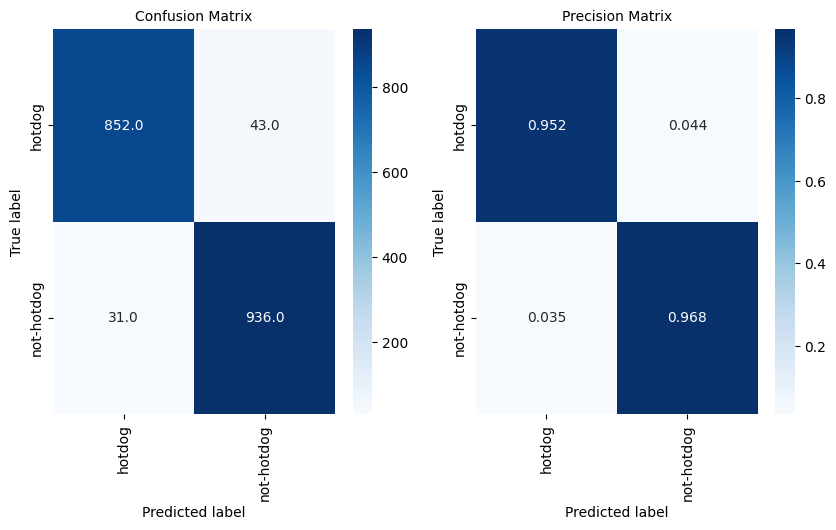

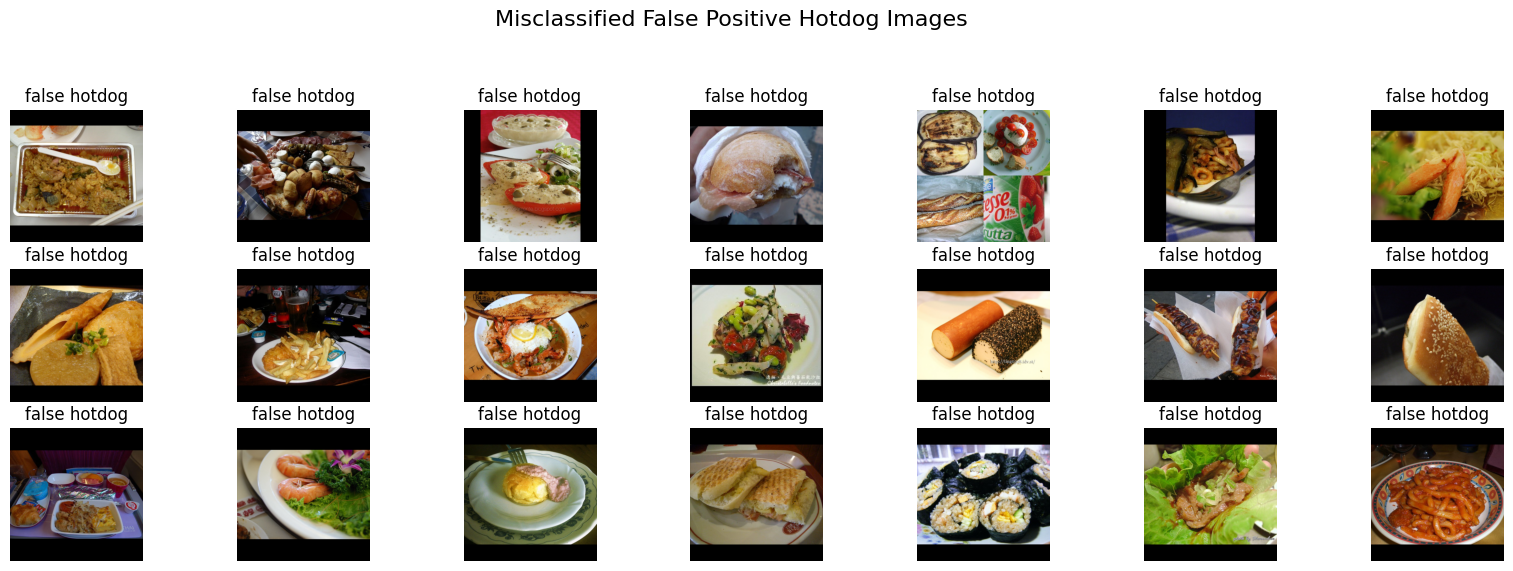

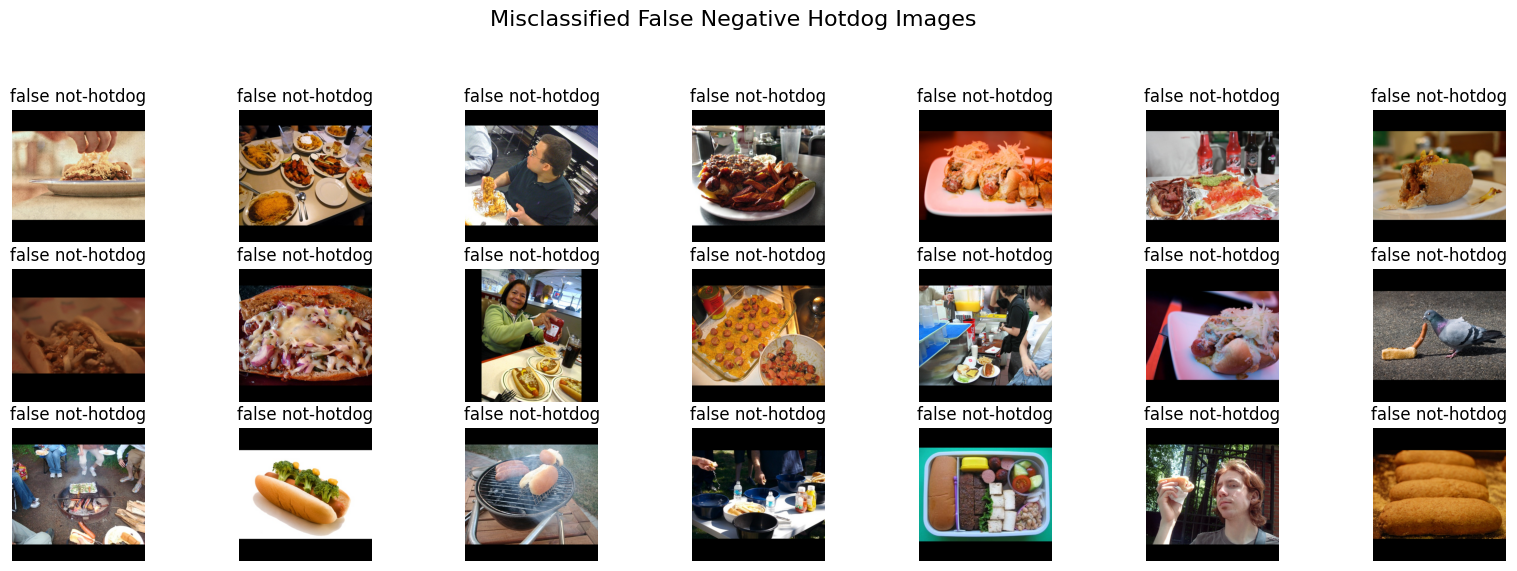

In [32]:
trainer.confusionMatrix(model, show_images = True)